## Tai Dinh, Week 4, Baseline Model

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn import linear_model as lm
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error

# Load in CSV's, Remove Outliers, and Select Features

In [ ]:
test_df = pd.read_csv('/content/test_df.csv')
train_df = pd.read_csv('/content/train_df.csv')

/tmp/ipykernel_712/3141949115.py:1: DtypeWarning: Columns (118,175) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv('/content/test_df.csv')
/tmp/ipykernel_712/3141949115.py:2: DtypeWarning: Columns (118,175) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv('/content/train_df.csv')


In [ ]:
train_df = train_df[(train_df["ClosePrice"] <= 600000000) & (train_df["ClosePrice"] > 0)]

In [ ]:
list(train_df.columns)

['AssociationFeeFrequency_Monthly',
 'AssociationFeeFrequency_None',
 'AssociationFeeFrequency_Quarterly',
 'AssociationFeeFrequency_SemiAnnually',
 'CountyOrParish_Amador',
 'CountyOrParish_Butte',
 'CountyOrParish_Calaveras',
 'CountyOrParish_Clark',
 'CountyOrParish_Colusa',
 'CountyOrParish_Contra Costa',
 'CountyOrParish_El Dorado',
 'CountyOrParish_Foreign Country',
 'CountyOrParish_Fresno',
 'CountyOrParish_Glenn',
 'CountyOrParish_Humboldt',
 'CountyOrParish_Imperial',
 'CountyOrParish_Inyo',
 'CountyOrParish_Kern',
 'CountyOrParish_Kings',
 'CountyOrParish_Lake',
 'CountyOrParish_Lassen',
 'CountyOrParish_Los Angeles',
 'CountyOrParish_Madera',
 'CountyOrParish_Marin',
 'CountyOrParish_Mariposa',
 'CountyOrParish_Mendocino',
 'CountyOrParish_Merced',
 'CountyOrParish_Modoc',
 'CountyOrParish_Mono',
 'CountyOrParish_Monterey',
 'CountyOrParish_Napa',
 'CountyOrParish_Nevada',
 'CountyOrParish_Orange',
 'CountyOrParish_Other',
 'CountyOrParish_Other State',
 'CountyOrParish_Plac

In [ ]:
cols = ["LivingArea", "Age", "Bed/Bath Ratio", "Living Area per Bedroom", "ParkingTotal", "BathroomsTotalInteger", "GarageSpaces", "AttachedGarageYN", "PoolPrivateYN", "ViewYN", "BedroomsTotal", "Stories", "AssociationFee"
, "AssociationFeeFrequency_Monthly", "AssociationFeeFrequency_None", "AssociationFeeFrequency_Quarterly", "AssociationFeeFrequency_SemiAnnually"
, 'CountyOrParish_Amador',
 'CountyOrParish_Butte',
 'CountyOrParish_Calaveras',
 'CountyOrParish_Clark',
 'CountyOrParish_Colusa',
 'CountyOrParish_Contra Costa',
 'CountyOrParish_El Dorado',
 'CountyOrParish_Foreign Country',
 'CountyOrParish_Fresno',
 'CountyOrParish_Glenn',
 'CountyOrParish_Humboldt',
 'CountyOrParish_Imperial',
 'CountyOrParish_Inyo',
 'CountyOrParish_Kern',
 'CountyOrParish_Kings',
 'CountyOrParish_Lake',
 'CountyOrParish_Lassen',
 'CountyOrParish_Los Angeles',
 'CountyOrParish_Madera',
 'CountyOrParish_Marin',
 'CountyOrParish_Mariposa',
 'CountyOrParish_Mendocino',
 'CountyOrParish_Merced',
 'CountyOrParish_Modoc',
 'CountyOrParish_Mono',
 'CountyOrParish_Monterey',
 'CountyOrParish_Napa',
 'CountyOrParish_Nevada',
 'CountyOrParish_Orange',
 'CountyOrParish_Other',
 'CountyOrParish_Other State',
 'CountyOrParish_Placer',
 'CountyOrParish_Plumas',
 'CountyOrParish_Riverside',
 'CountyOrParish_Sacramento',
 'CountyOrParish_San Benito',
 'CountyOrParish_San Bernardino',
 'CountyOrParish_San Diego',
 'CountyOrParish_San Francisco',
 'CountyOrParish_San Joaquin',
 'CountyOrParish_San Luis Obispo',
 'CountyOrParish_San Mateo',
 'CountyOrParish_Santa Barbara',
 'CountyOrParish_Santa Clara',
 'CountyOrParish_Santa Cruz',
 'CountyOrParish_Shasta',
 'CountyOrParish_Sierra',
 'CountyOrParish_Siskiyou',
 'CountyOrParish_Solano',
 'CountyOrParish_Sonoma',
 'CountyOrParish_Stanislaus',
 'CountyOrParish_Sutter',
 'CountyOrParish_Tehama',
 'CountyOrParish_Trinity',
 'CountyOrParish_Tulare',
 'CountyOrParish_Tuolumne',
 'CountyOrParish_Ventura',
 'CountyOrParish_Yolo',
 'CountyOrParish_Yuba',
 'DistrictName_Apple Valley Unified',
 'DistrictName_Bear Valley Unified',
 'DistrictName_Beaumont Unified',
 'DistrictName_Capistrano Unified',
 'DistrictName_Chico Unified',
 'DistrictName_Chino Valley Unified',
 'DistrictName_Coachella Valley Unified',
 'DistrictName_Conejo Valley Unified',
 'DistrictName_Corona-Norco Unified',
 'DistrictName_Desert Sands Unified',
 'DistrictName_Fontana Unified',
 'DistrictName_Fremont Unified',
 'DistrictName_Garden Grove Unified',
 'DistrictName_Glendale Unified',
 'DistrictName_Hemet Unified',
 'DistrictName_Hesperia Unified',
 'DistrictName_Irvine Unified',
 'DistrictName_Lake Elsinore Unified',
 'DistrictName_Long Beach Unified',
 'DistrictName_Los Angeles Unified',
 'DistrictName_Lucia Mar Unified',
 'DistrictName_Moreno Valley Unified',
 'DistrictName_Morongo Unified',
 'DistrictName_Mt. Diablo Unified',
 'DistrictName_Murrieta Valley Unified',
 'DistrictName_Newport-Mesa Unified',
 'DistrictName_None',
 'DistrictName_Oakland Unified',
 'DistrictName_Oceanside Unified',
 'DistrictName_Orange Unified',
 'DistrictName_Other',
 'DistrictName_Palm Springs Unified',
 'DistrictName_Pasadena Unified',
 'DistrictName_Placentia-Yorba Linda Unified',
 'DistrictName_Poway Unified',
 'DistrictName_Redlands Unified',
 'DistrictName_Rim of the World Unified',
 'DistrictName_Riverside Unified',
 'DistrictName_Saddleback Valley Unified',
 'DistrictName_San Bernardino City Unified',
 'DistrictName_San Diego Unified',
 'DistrictName_San Jose Unified',
 'DistrictName_San Marcos Unified',
 'DistrictName_San Ramon Valley Unified',
 'DistrictName_Simi Valley Unified',
 'DistrictName_Temecula Valley Unified',
 'DistrictName_Torrance Unified',
 'DistrictName_Vista Unified',
 'DistrictName_West Contra Costa Unified']

 #,'StateOrProvince_CA'
X_train = train_df[cols]
Y_train = train_df["ClosePrice"]
X_test = test_df[cols]
Y_test = test_df["ClosePrice"]

# Train Linear Regression Model

In [ ]:
model = lm.LinearRegression()
model.fit(X_train, Y_train)

preds = model.predict(X_test)

# Find $R^2$ and Plot


0.5912357989002195
981831.4434953366


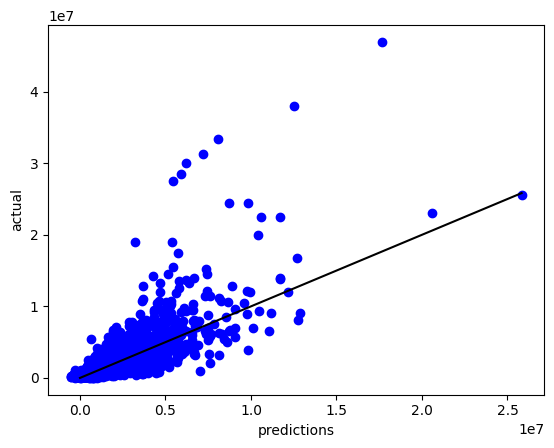

In [ ]:
print(r2_score(Y_test, preds))
print(root_mean_squared_error(Y_test, preds))

plt.scatter(preds, Y_test, color='blue')
plt.plot([0, max(preds)], [0, max(preds)], color = 'black')
plt.xlabel('predictions')
plt.ylabel('actual')
plt.show()


The baseline model does not do very well and has a long way to go.